# Overlap quota: does it help to separate colliding classes? (axis-200-900)

The overlap quota adds synthetic tokens for classes that share a bin with another class in a training pixel (spectral collisions): a 'seed' of where each colliding class is. If it works, the model should discriminate the annotated class of a colliding pair from its partner better than the baseline and than the matched variant without the quota.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* **Collision pairs** are the class pairs co-annotated at the same bin of the same training pixel (regenerated
  synthetic artifact). The analysis is limited to pairs with at least `minimum_pair_pixels` evaluable pixels.
* **Matched controls.** P3 vs P2 and P5 vs P4 (joint and staged) differ only in the overlap quota.
* **Secondary analysis.** Pixels grouped by their number of annotated classes (spatial co-occurrence), with the
  label-ranking average precision (LRAP) per group.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

* For a pair $(a, b)$ and pixels where exactly one of them is annotated: *discrimination* = fraction of pixels in
  which the annotated class scores higher; *margin* = mean logit difference (annotated - partner); *false-positive
  rate when the partner is present* = rate at which the absent class is predicted ($p \ge 0.5$) where its partner
  is annotated; *false-positive lift* = that rate minus the rate where both are absent (lower is better).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "overlap_classes"
AXIS = "axis-200-900"
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

pairs = table('pairs')
pair_summary = table('pair_summary')
baseline_summary = table('baseline_summary')
PAIRS = settings['targeted']['overlap']['pairs']
TREATED = list(PAIRS)
PAIR_LABELS = {treated: f"{VARIANT_LABELS[treated]} - {VARIANT_LABELS[control]}" for treated, control in PAIRS.items()}
print('Collision pairs:', metadata['collision_pairs'], '| overlap classes:', metadata['overlap_classes'],
      '| minimum pair pixels:', metadata['minimum_pair_pixels'])

Analysis: overlap_classes | axis: axis-200-900 | stage: None | models: 155
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Collision pairs: 4 | overlap classes: 8 | minimum pair pixels: 5


## Producing the tables this notebook reads

### Methodology

#### Implementation

`overlap_classes` reads the collision pairs of the regenerated synthetic artifact, the stored logits and the
annotations of every model's evaluation populations, and computes the pairwise discrimination, the class-set
metrics and the co-occurrence LRAP.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis overlap_classes > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute metrics of the targeted class sets against the real-only baseline

### Methodology

#### Theoretical

The improvements and matched controls below are differences; this section shows the level of every
targeted class-set metric for the real-only baseline and every variant at every stage.

#### Implementation

`set_metrics` holds one value per model, class set, metric and evaluation population.

#### Figure descriptions

        Figure: one panel per metric; x = real-only baseline and the stages (every variant's repetitions pooled per
        stage; 50 models per stage against 5 baseline models), violin and points = models. Tables (one per metric): rows
        = baseline and variants, columns = stages; the baseline row repeats the baseline value in every stage column so
        that each cell is compared with it.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

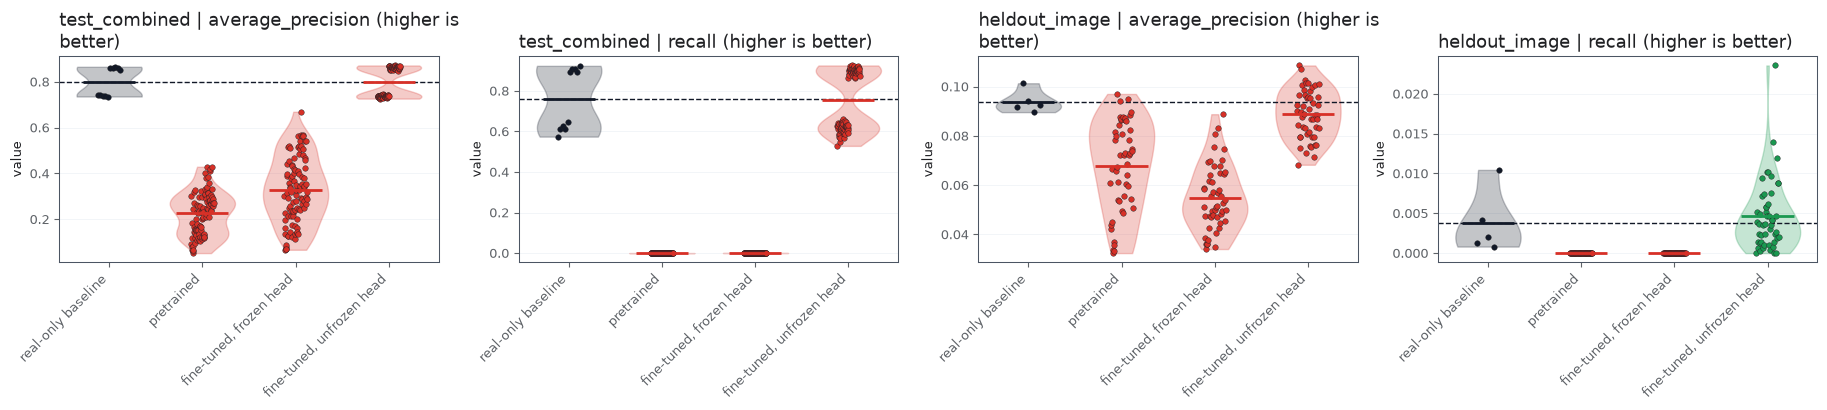

test_combined | average_precision


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.799 +/- 0.064,0.799 +/- 0.064,0.799 +/- 0.064
P0_single,0.197 +/- 0.079,0.254 +/- 0.072,0.803 +/- 0.069
P1_permutation,0.096 +/- 0.033,0.116 +/- 0.046,0.794 +/- 0.064
P2_joint_base,0.288 +/- 0.083,0.455 +/- 0.078,0.798 +/- 0.067
P2_staged_base,0.209 +/- 0.079,0.257 +/- 0.088,0.801 +/- 0.065
P3_joint_overlap,0.271 +/- 0.106,0.499 +/- 0.097,0.799 +/- 0.065
P3_staged_overlap,0.227 +/- 0.065,0.278 +/- 0.070,0.802 +/- 0.067
P4_joint_rare,0.266 +/- 0.109,0.464 +/- 0.087,0.799 +/- 0.066
P4_staged_rare,0.212 +/- 0.070,0.260 +/- 0.081,0.799 +/- 0.067


test_combined | recall


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.759 +/- 0.154,0.759 +/- 0.154,0.759 +/- 0.154
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.746 +/- 0.150
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.761 +/- 0.159
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.740 +/- 0.169
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.756 +/- 0.149
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.768 +/- 0.143
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.757 +/- 0.142
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.756 +/- 0.154
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.761 +/- 0.152


heldout_image | average_precision


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.094 +/- 0.005,0.094 +/- 0.005,0.094 +/- 0.005
P0_single,0.052 +/- 0.011,0.051 +/- 0.008,0.089 +/- 0.015
P1_permutation,0.034 +/- 0.002,0.036 +/- 0.001,0.084 +/- 0.009
P2_joint_base,0.075 +/- 0.007,0.058 +/- 0.013,0.094 +/- 0.010
P2_staged_base,0.070 +/- 0.020,0.056 +/- 0.007,0.094 +/- 0.008
P3_joint_overlap,0.085 +/- 0.008,0.057 +/- 0.016,0.089 +/- 0.012
P3_staged_overlap,0.068 +/- 0.018,0.054 +/- 0.016,0.089 +/- 0.010
P4_joint_rare,0.073 +/- 0.014,0.059 +/- 0.015,0.088 +/- 0.011
P4_staged_rare,0.075 +/- 0.015,0.056 +/- 0.010,0.084 +/- 0.009


heldout_image | recall


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.004 +/- 0.004,0.004 +/- 0.004,0.004 +/- 0.004
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.002 +/- 0.002
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.002 +/- 0.002
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.005 +/- 0.003
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.003 +/- 0.003
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.006 +/- 0.002
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.005 +/- 0.004
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.006 +/- 0.003
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.004 +/- 0.006


In [4]:
frame_abs = table('set_metrics')

SELECTORS_ABS = [["test_combined | average_precision", {"evaluation": "test_combined", "metric": "average_precision"}, "higher"], ["test_combined | recall", {"evaluation": "test_combined", "metric": "recall"}, "higher"], ["heldout_image | average_precision", {"evaluation": "heldout_image", "metric": "average_precision"}, "higher"], ["heldout_image | recall", {"evaluation": "heldout_image", "metric": "recall"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(frame_abs, panels=[(label, selector, direction) for label, selector, direction in SELECTORS_ABS], group='stage',
                      order=STAGE_ORDER, labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for label, selector, direction in SELECTORS_ABS:
    rows = frame_abs
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    print(label)
    display(figures.comparison_table(grid, index='variant', columns='stage', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=STAGES, direction={stage: direction for stage in STAGES}))

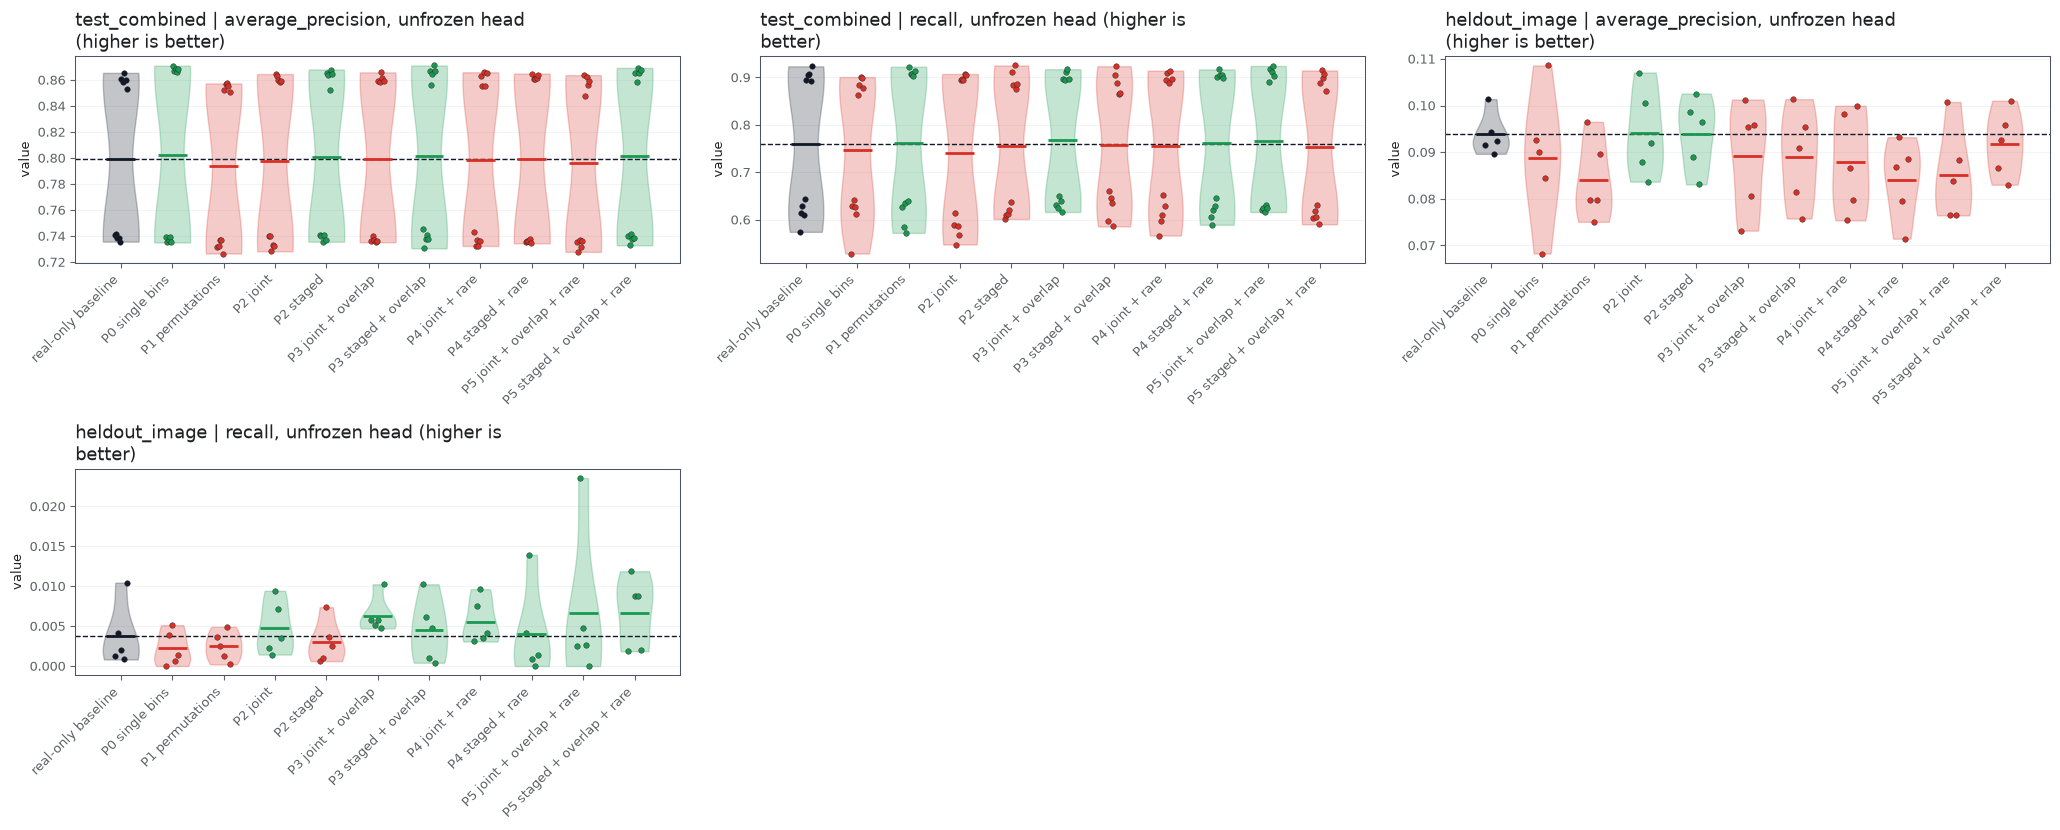

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- test_combined | average_precision (by stage, variants pooled): baseline 0.7992; others 0.2255-0.7991; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7991), worst pretrained (0.2255).
- test_combined | average_precision (unfrozen head, per variant): baseline 0.7992; others 0.7936-0.8026; 4 of 10 better than the baseline; best P0 single bins (0.8026), worst P1 permutations (0.7936).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.8026 vs baseline 0.7992).
- test_combined | recall (by stage, variants pooled): baseline 0.7594; others 2.195e-07-0.7565; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7565), worst fine-tuned, frozen head (2.195e-07).
- test_combined | recall (unfrozen head, per variant): baseline 0.7594; others 0.74-0.768; 4 of 10 better than the baseline; best P3 joint + overlap (0.768), worst P2 joint (0.74).
  best single cell: P3 joint + overlap, fine-tuned, unfrozen head (0.768 vs baseline 0.7594).
- heldout_image | average_precision (by stage, variants pooled): baseline 0.09385; others 0.05492-0.08881; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.08881), worst fine-tuned, frozen head (0.05492).
- heldout_image | average_precision (unfrozen head, per variant): baseline 0.09385; others 0.08393-0.09421; 2 of 10 better than the baseline; best P2 joint (0.09421), worst P4 staged + rare (0.08393).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.09421 vs baseline 0.09385).
- heldout_image | recall (by stage, variants pooled): baseline 0.003728; others 0-0.004629; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.004629), worst fine-tuned, frozen head (0).
- heldout_image | recall (unfrozen head, per variant): baseline 0.003728; others 0.002212-0.006678; 7 of 10 better than the baseline; best P5 joint + overlap + rare (0.006678), worst P0 single bins (0.002212).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.006678 vs baseline 0.003728).

### Notes

## Collision pairs and their support

### Methodology

#### Theoretical

The pairs are the classes the overlap quota targets. Their support on the evaluation pixels bounds the power
of the analysis.

#### Implementation

`pairs` (training co-annotations and pixels) and `pair_summary` (number of pairs with enough pixels per evaluation).

#### Figure descriptions

No figure.

In [6]:
display(pairs)
display(pair_summary.groupby('evaluation').pairs.agg(['min', 'max']))

,class_a,class_b,co_annotations,pixels,class_a_name,class_b_name
0,17,328,1559,1559,C10H9Cl3O2|-H,C3H8O10P2|-H
1,356,409,3133,3133,C42H80NO10P|-H,C45H76NO8P|-H
2,402,426,21599,21599,C44H85NO11S|-H,C46H78NO10P|-H
3,437,459,25813,25813,C46H89NO11S|-H,C48H82NO10P|-H


,min,max
evaluation,,
heldout_image,0,0
test_combined,4,4


### Remarks

- 4 collision pairs, 1559-25813 training pixels each: C10H9Cl3O2|-H / C3H8O10P2|-H; C42H80NO10P|-H / C45H76NO8P|-H; C44H85NO11S|-H / C46H78NO10P|-H; C46H89NO11S|-H / C48H82NO10P|-H.
- Supported pairs on the held-out images: 0; the pair analysis is therefore limited to test + extension.

### Notes

## Pair discrimination against the baseline

### Methodology

#### Theoretical

Pixel-weighted mean over the supported pairs of discrimination, margin and false-positive lift, paired
against the baseline.

#### Implementation

`baseline_improvements` and `baseline_summary` (test + extension; the held-out images contain no supported pair).

#### Figure descriptions

Forest plot: rows = variants, panels = metric x stage.

discrimination                                         margin                                    false_positive_lift                                   
stage                frozen_head pretrained real_only unfrozen_head frozen_head pretrained real_only unfrozen_head         frozen_head pretrained real_only unfrozen_head
variant                                                                                                                                                                  
baseline                     NaN        NaN      0.87           NaN         NaN        NaN     4.401           NaN                 NaN        NaN      0.09           NaN
P0_single                  0.463      0.454       NaN         0.871      -0.015      0.029       NaN         4.029               0.000      0.000       NaN         0.088
P1_permutation             0.405      0.509       NaN         0.868      -0.052     -0.013       NaN         4.338               0.000      0.000       NaN         0.094
P2_joint_base              0.677      0.604       NaN         0.862       0.213      0.147       NaN         4.041               0.000      0.000       NaN         0.081
P2_staged_base             0.560      0.604       NaN         0.874       0.074      0.083       NaN         4.219               0.000      0.000       NaN         0.088
P3_joint_overlap           0.466      0.450       NaN         0.874       0.041     -0.075       NaN         4.047              -0.000      0.000       NaN         0.097
P3_staged_overlap          0.556      0.476       NaN         0.879       0.008      0.005       NaN         4.105              -0.001     -0.001       NaN         0.095
P4_joint_rare              0.451      0.592       NaN         0.870      -0.034      0.049       NaN         4.156               0.000      0.000       NaN         0.092
P4_staged_rare             0.292      0.341       NaN         0.870      -0.307     -0.178       NaN         4.260              -0.000     -0.001       NaN         0.089
P5_joint_all               0.335      0.377       NaN         0.867      -0.205     -0.165       NaN         4.309              -0.000     -0.000       NaN         0.093
P5_staged_all              0.333      0.334       NaN         0.872      -0.161     -0.179       NaN         4.284              -0.002     -0.003       NaN         0.089

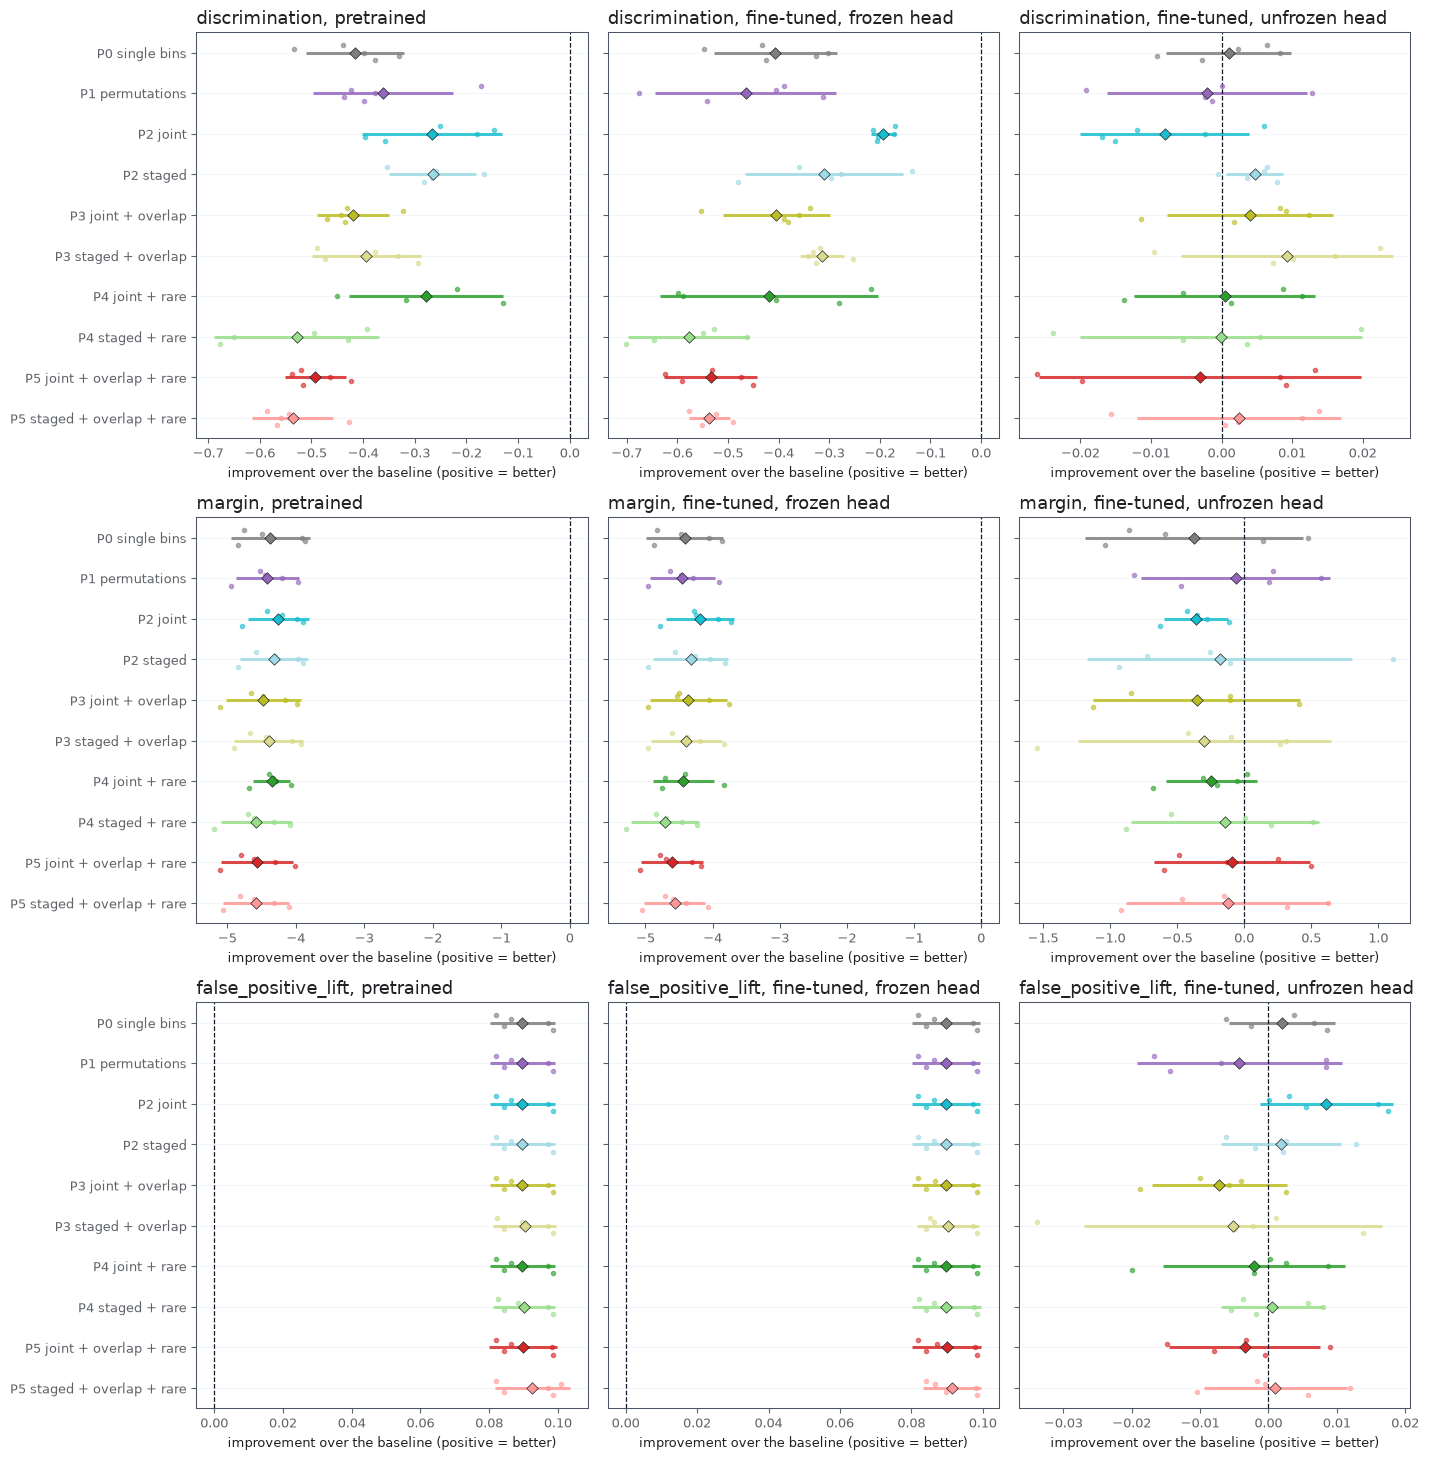

In [7]:
rows = baseline_summary[baseline_summary.evaluation == 'test_combined']
panels = [(f"{metric}, {STAGE_LABELS[stage]}", {'metric': metric, 'stage': stage})
          for metric in ['discrimination', 'margin', 'false_positive_lift'] for stage in STAGES]
paired = table('baseline_improvements')
figures.improvement_forest(rows, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           paired=paired[paired.evaluation == 'test_combined'], columns=3, theme=theme);
display(pair_summary[pair_summary.evaluation == 'test_combined'].groupby(['variant', 'stage'])[['discrimination', 'margin', 'false_positive_lift']]
        .mean().unstack('stage').reindex(ORDER).round(3))

### Remarks

- Baseline: discrimination 0.87, margin 4.4, false-positive lift 0.0897. Unfrozen variants: discrimination 0.862-0.879, lift 0.0812-0.0968.
- Pretrained and frozen stages: discrimination 0.292-0.677 (chance = 0.5; from well below to modestly above it) and a false-positive lift of 0. The zero lift is trivial: these heads never reach p = 0.5, so they have no false positives at all; their 'improvement' in lift over the baseline is an artefact of the threshold.
- Unfrozen stage against the baseline:
  - discrimination: better than the baseline for P2 staged; worse for none.
  - false_positive_lift: better than the baseline for none; worse for none.
  - false_positive_rate_when_partner_present: better than the baseline for none; worse for none.
  - margin: better than the baseline for none; worse for P2 joint.

### Notes

## Overlap quota against the matched control

### Methodology

#### Theoretical

Variant with the overlap quota minus the same construction without it, paired by stage and repetition.

#### Implementation

`control_summary`.

#### Figure descriptions

Forest plot: rows = treated variants, panels = metric x stage.

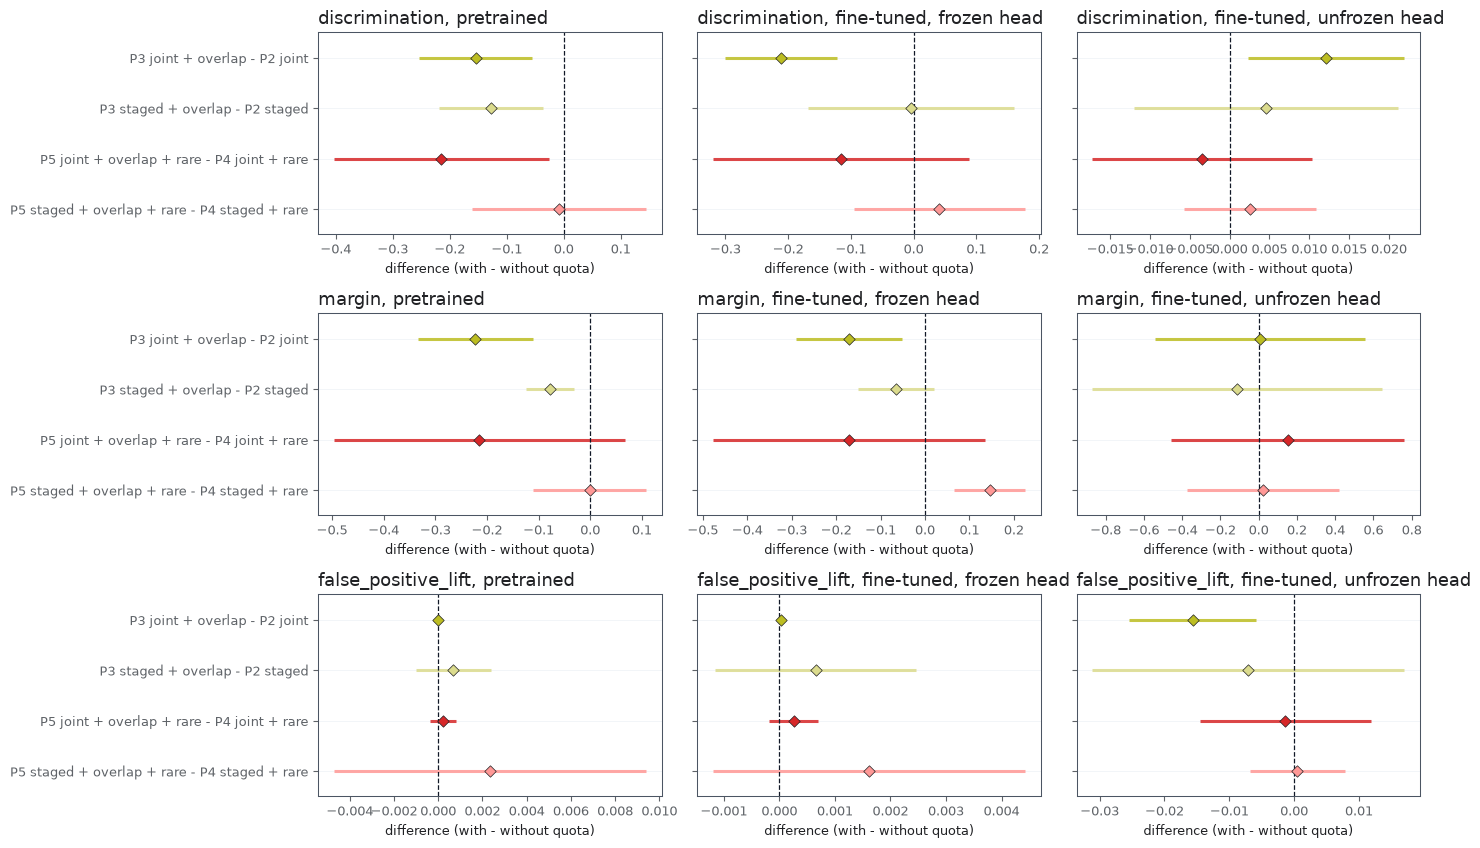

In [8]:
rows = table('control_summary')
rows = rows[rows.evaluation == 'test_combined']
figures.improvement_forest(rows, panels=panels, variants=TREATED, labels=PAIR_LABELS, colors=VARIANT_COLORS, columns=3,
                           xlabel='difference (with - without quota)', theme=theme);

### Remarks

- pretrained, P3 joint + overlap - P2 joint, discrimination: -0.154 [-0.254, -0.055] (worse with the quota).
- frozen head, P3 joint + overlap - P2 joint, discrimination: -0.211 [-0.301, -0.121] (worse with the quota).
- unfrozen head, P3 joint + overlap - P2 joint, discrimination: 0.0121 [0.00227, 0.0219] (better with the quota).
- pretrained, P3 joint + overlap - P2 joint, margin: -0.222 [-0.334, -0.111] (worse with the quota).
- frozen head, P3 joint + overlap - P2 joint, margin: -0.171 [-0.291, -0.052] (worse with the quota).
- unfrozen head, P3 joint + overlap - P2 joint, false_positive_rate_when_partner_present: -0.0162 [-0.0268, -0.00568] (worse with the quota).
- unfrozen head, P3 joint + overlap - P2 joint, false_positive_lift: -0.0156 [-0.0254, -0.00582] (worse with the quota).
- pretrained, P3 staged + overlap - P2 staged, discrimination: -0.128 [-0.219, -0.0369] (worse with the quota).
- pretrained, P3 staged + overlap - P2 staged, margin: -0.0777 [-0.123, -0.032] (worse with the quota).
- pretrained, P5 joint + overlap + rare - P4 joint + rare, discrimination: -0.214 [-0.403, -0.0255] (worse with the quota).
- frozen head, P5 staged + overlap + rare - P4 staged + rare, margin: 0.146 [0.0663, 0.225] (better with the quota).
- 37 of 48 matched cells are inconclusive.

### Notes

## Overlap classes against the other eligible classes

### Methodology

#### Theoretical

Macro AP over the overlap classes and over the other eligible classes, against the baseline and against the matched control.

#### Implementation

`set_summary` and `set_control_summary`.

#### Figure descriptions

No figure; interval strings per variant, class set and stage (test + extension).

In [9]:
sets = table('set_summary')
sets = sets[(sets.metric == 'average_precision') & (sets.evaluation == 'test_combined')]
display(sets.assign(result=interval(sets)).pivot_table(index='variant', columns=['ranking', 'stage'], values='result', aggfunc='first').reindex(VARIANTS))
controls = table('set_control_summary')
controls = controls[(controls.metric == 'average_precision') & (controls.evaluation == 'test_combined')]
display(controls.assign(result=interval(controls)).pivot_table(index='variant', columns=['ranking', 'stage'], values='result', aggfunc='first').reindex(TREATED))

ranking                             other_eligible                                                                                                   overlap                                   \
stage                                  frozen_head                       pretrained                           unfrozen_head                      frozen_head                       pretrained   
variant                                                                                                                                                                                         
P0_single          -0.557 [-0.604, -0.509] (+0/-5)  -0.621 [-0.664, -0.577] (+0/-5)       0.00858 [0.00278, 0.0144] (+5/-0)  -0.533 [-0.612, -0.454] (+0/-5)  -0.584 [-0.697, -0.472] (+0/-5)   
P1_permutation     -0.703 [-0.736, -0.671] (+0/-5)  -0.733 [-0.745, -0.722] (+0/-5)  -0.00503 [-0.00911, -0.000939] (+0/-5)  -0.663 [-0.675, -0.652] (+0/-5)  -0.673 [-0.687, -0.659] (+0/-5)   
P2_joint_base      -0.361 [-0.429, -0.292] (+0/-5)  -0.513 [-0.566, -0.461] (+0/-5)     0.00164 [-0.00416, 0.00744] (+3/-2)  -0.328 [-0.423, -0.234] (+0/-5)   -0.51 [-0.602, -0.417] (+0/-5)   
P2_staged_base     -0.548 [-0.627, -0.468] (+0/-5)   -0.609 [-0.65, -0.569] (+0/-5)      0.00328 [-0.00878, 0.0153] (+4/-1)   -0.536 [-0.63, -0.443] (+0/-5)  -0.571 [-0.689, -0.453] (+0/-5)   
P3_joint_overlap   -0.298 [-0.382, -0.214] (+0/-5)  -0.499 [-0.555, -0.442] (+0/-5)     0.00135 [-0.00219, 0.00489] (+4/-1)  -0.303 [-0.409, -0.197] (+0/-5)  -0.558 [-0.624, -0.493] (+0/-5)   
P3_staged_overlap  -0.542 [-0.599, -0.485] (+0/-5)  -0.591 [-0.643, -0.538] (+0/-5)       0.00568 [-0.0029, 0.0143] (+3/-2)    -0.5 [-0.587, -0.414] (+0/-5)  -0.553 [-0.629, -0.476] (+0/-5)   
P4_joint_rare      -0.323 [-0.372, -0.273] (+0/-5)  -0.514 [-0.603, -0.425] (+0/-5)     0.00161 [-0.00644, 0.00966] (+3/-2)  -0.348 [-0.408, -0.288] (+0/-5)  -0.553 [-0.648, -0.458] (+0/-5)   
P4_staged_rare     -0.541 [-0.604, -0.477] (+0/-5)   -0.593 [-0.626, -0.56] (+0/-5)     0.00292 [-0.00407, 0.00992] (+4/-1)  -0.537 [-0.609, -0.464] (+0/-5)  -0.581 [-0.648, -0.513] (+0/-5)   
P5_joint_all        -0.373 [-0.44, -0.305] (+0/-5)  -0.539 [-0.623, -0.455] (+0/-5)     -0.0016 [-0.00969, 0.00649] (+2/-3)  -0.361 [-0.471, -0.251] (+0/-5)   -0.52 [-0.622, -0.419] (+0/-5)   
P5_staged_all      -0.555 [-0.592, -0.517] (+0/-5)  -0.586 [-0.596, -0.577] (+0/-5)     0.00578 [-0.000656, 0.0122] (+5/-0)  -0.524 [-0.674, -0.375] (+0/-5)  -0.571 [-0.635, -0.508] (+0/-5)   

ranking                                                    
stage                                       unfrozen_head  
variant                                                    
P0_single            -0.00173 [-0.00474, 0.00129] (+1/-4)  
P1_permutation      -0.00618 [-0.0114, -0.000929] (+0/-5)  
P2_joint_base       -0.00416 [-0.00893, 0.000612] (+0/-5)  
P2_staged_base       -6.24e-05 [-0.00232, 0.0022] (+3/-2)  
P3_joint_overlap    -0.00205 [-0.00453, 0.000423] (+1/-4)  
P3_staged_overlap   -0.000537 [-0.00799, 0.00692] (+3/-2)  
P4_joint_rare        -0.00286 [-0.00848, 0.00276] (+2/-3)  
P4_staged_rare     -0.00295 [-0.00583, -8.08e-05] (+0/-5)  
P5_joint_all          -0.00518 [-0.0118, 0.00148] (+1/-4)  
P5_staged_all        -0.00064 [-0.00655, 0.00527] (+2/-3)

ranking                                 other_eligible                                                                                                      overlap  \
stage                                      frozen_head                         pretrained                          unfrozen_head                        frozen_head   
variant                                                                                                                                                               
P3_joint_overlap       0.0625 [-0.0497, 0.175] (+3/-2)   0.0146 [-0.0105, 0.0397] (+4/-1)  -0.000287 [-0.00593, 0.00535] (+3/-2)      0.0253 [-0.119, 0.17] (+2/-3)   
P3_staged_overlap    0.00568 [-0.0335, 0.0449] (+3/-2)   0.0185 [-0.0612, 0.0983] (+3/-2)     0.00239 [-0.00662, 0.0114] (+4/-1)    0.0358 [-0.0732, 0.145] (+3/-2)   
P5_joint_all       -0.0499 [-0.0972, -0.00257] (+0/-5)  -0.0248 [-0.0944, 0.0449] (+3/-2)    -0.00321 [-0.0082, 0.00178] (+2/-3)  -0.0131 [-0.0783, 0.0521] (+2/-3)   
P5_staged_all        -0.0139 [-0.0576, 0.0298] (+3/-2)  0.00709 [-0.0263, 0.0404] (+3/-2)    0.00285 [-0.00225, 0.00796] (+4/-1)      0.0124 [-0.155, 0.18] (+2/-3)   

ranking                                                                                      
stage                                     pretrained                          unfrozen_head  
variant                                                                                      
P3_joint_overlap     -0.0487 [-0.14, 0.0429] (+1/-4)    0.00211 [-0.00357, 0.00778] (+4/-1)  
P3_staged_overlap    0.0186 [-0.0653, 0.102] (+3/-2)  -0.000474 [-0.00717, 0.00623] (+4/-1)  
P5_joint_all         0.0326 [-0.0791, 0.144] (+4/-1)   -0.00232 [-0.00649, 0.00184] (+1/-4)  
P5_staged_all      0.00911 [-0.0502, 0.0684] (+4/-1)     0.00231 [-0.00258, 0.0072] (+3/-2)

### Remarks

- Macro AP per class set (overlap / other eligible) against the matched control, cells excluding zero: frozen head P5 joint + overlap + rare test+ext other_eligible -0.0499 [-0.0972, -0.00257] (35 of 36 cells inconclusive).

### Notes

## Ranking quality by number of annotated classes per pixel

### Methodology

#### Theoretical

Label-ranking average precision per pixel group (1, 2-3, 4-7, 8+ annotated classes). Pixels with many
co-occurring classes are where overlapping signals are most likely; an overlap-quota benefit should appear
there first.

#### Implementation

`cooccurrence_summary` (paired against the baseline).

#### Figure descriptions

Forest plot: rows = variants, panels = pixel group x evaluation at the unfrozen stage.

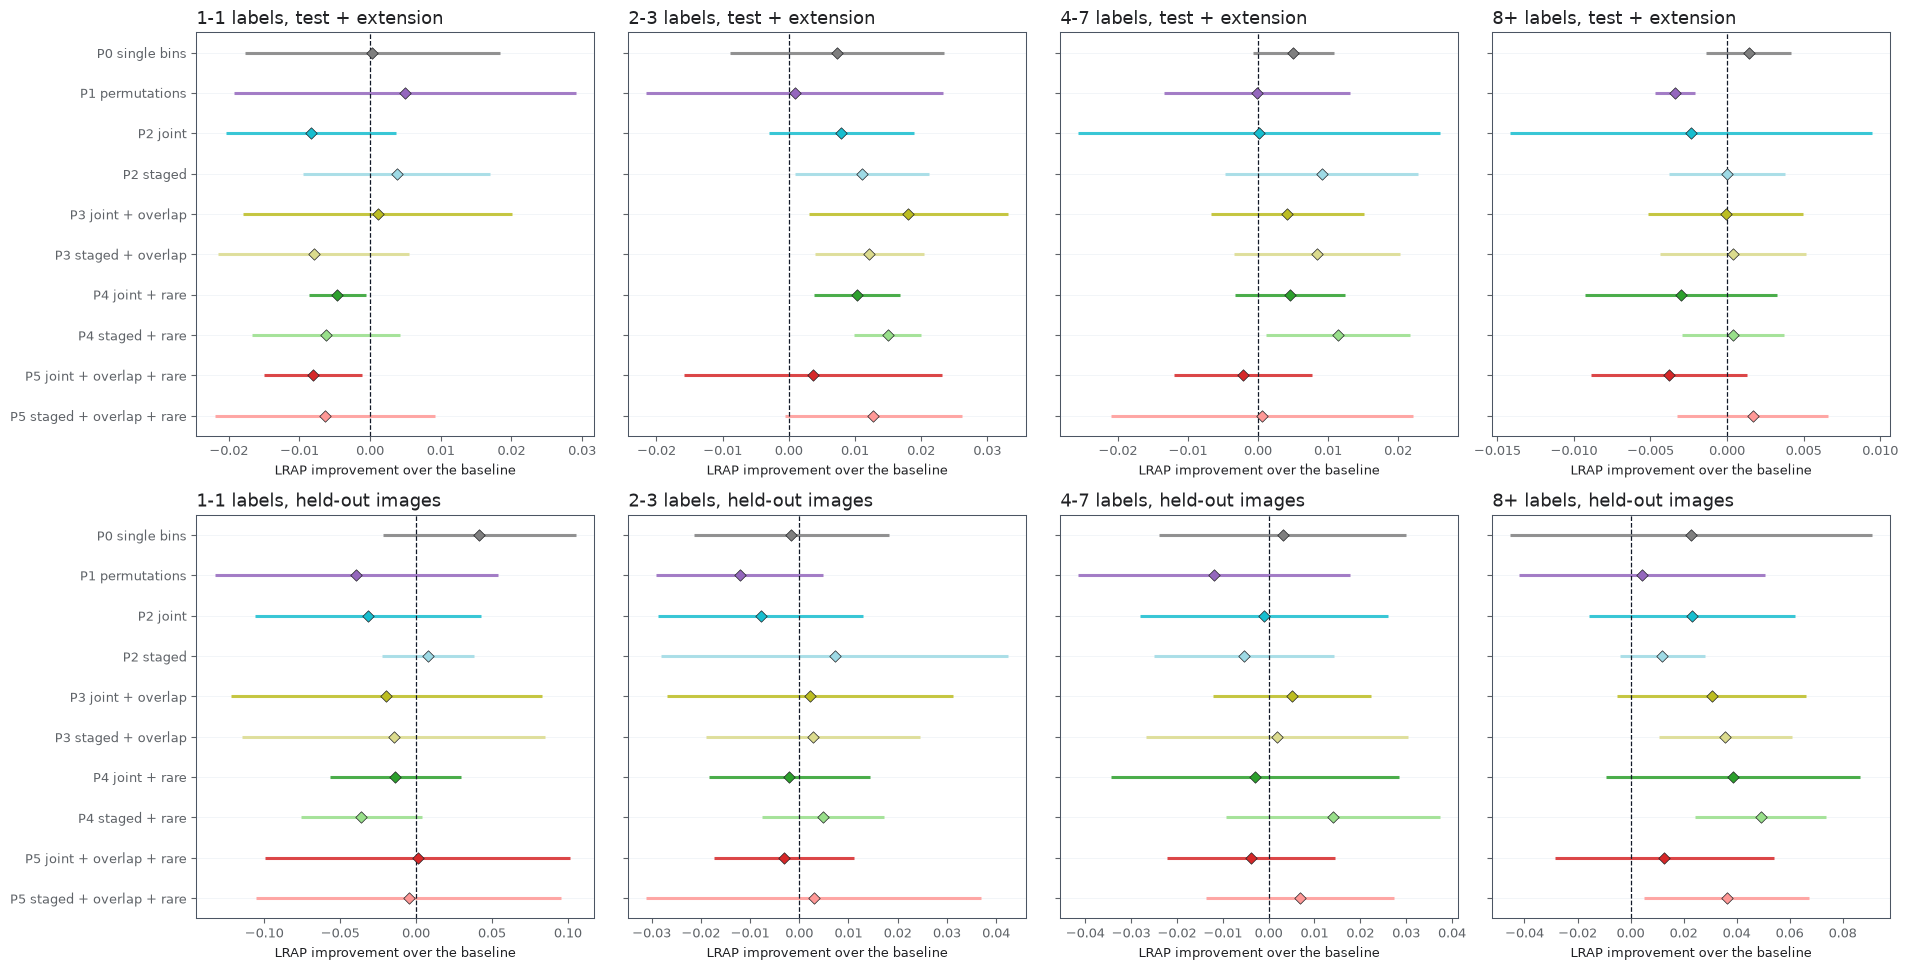

In [10]:
cooccurrence = table('cooccurrence_summary')
cooccurrence = cooccurrence[cooccurrence.stage == 'unfrozen_head']
panels = [(f"{group} labels, {EVALUATION_NAMES[evaluation]}", {'ranking': group, 'evaluation': evaluation})
          for evaluation in ['test_combined', 'heldout_image'] for group in ['1-1', '2-3', '4-7', '8+']]
figures.improvement_forest(cooccurrence, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, columns=4,
                           xlabel='LRAP improvement over the baseline', theme=theme);

### Remarks

- held-out, 1-1 labels: LRAP improvement -0.0395 to 0.0418; 0 better, 0 worse of 10 variants.
- held-out, 2-3 labels: LRAP improvement -0.0121 to 0.0072; 0 better, 0 worse of 10 variants.
- held-out, 4-7 labels: LRAP improvement -0.0118 to 0.0141; 0 better, 0 worse of 10 variants.
- held-out, 8+ labels: LRAP improvement 0.00441 to 0.0492; 3 better, 0 worse of 10 variants.
- test+ext, 1-1 labels: LRAP improvement -0.00837 to 0.00493; 0 better, 2 worse of 10 variants.
- test+ext, 2-3 labels: LRAP improvement 0.000883 to 0.0181; 5 better, 0 worse of 10 variants.
- test+ext, 4-7 labels: LRAP improvement -0.00213 to 0.0114; 1 better, 0 worse of 10 variants.
- test+ext, 8+ labels: LRAP improvement -0.00379 to 0.00167; 0 better, 1 worse of 10 variants.

### Notes

## Results / Summary

### LLM

- **Observed:** the overlap quota targets 8 classes in 4 collision pairs (1559-25813 training pixels each); no pair is supported on the held-out images, so only test + extension can be analysed, and the pixel-weighted pair summary is dominated by the two large pairs.
- **Observed:** at the unfrozen stage every variant discriminates the pairs like the baseline (0.86-0.88 against 0.87). The only matched effect there is mixed: P3 joint - P2 joint discriminates slightly better (+0.012) but predicts the absent partner more often (false-positive lift +0.016 worse). Before full fine-tuning the quota lowers discrimination on this axis (P3 joint, P3 staged, P5 joint against their controls).
- **Interpretation:** the 'seed where each colliding class is' does not improve the separation of colliding classes after real fine-tuning; with 4 pairs and no held-out support the test has low power.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- test_combined | average_precision (by stage, variants pooled): baseline 0.7992; others 0.2255-0.7991; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7991), worst pretrained (0.2255).
- test_combined | average_precision (unfrozen head, per variant): baseline 0.7992; others 0.7936-0.8026; 4 of 10 better than the baseline; best P0 single bins (0.8026), worst P1 permutations (0.7936).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.8026 vs baseline 0.7992).
- test_combined | recall (by stage, variants pooled): baseline 0.7594; others 2.195e-07-0.7565; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7565), worst fine-tuned, frozen head (2.195e-07).
- test_combined | recall (unfrozen head, per variant): baseline 0.7594; others 0.74-0.768; 4 of 10 better than the baseline; best P3 joint + overlap (0.768), worst P2 joint (0.74).
  best single cell: P3 joint + overlap, fine-tuned, unfrozen head (0.768 vs baseline 0.7594).
- heldout_image | average_precision (by stage, variants pooled): baseline 0.09385; others 0.05492-0.08881; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.08881), worst fine-tuned, frozen head (0.05492).
- heldout_image | average_precision (unfrozen head, per variant): baseline 0.09385; others 0.08393-0.09421; 2 of 10 better than the baseline; best P2 joint (0.09421), worst P4 staged + rare (0.08393).
  best single cell: P2 joint, fine-tuned, unfrozen head (0.09421 vs baseline 0.09385).
- heldout_image | recall (by stage, variants pooled): baseline 0.003728; others 0-0.004629; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.004629), worst fine-tuned, frozen head (0).
- heldout_image | recall (unfrozen head, per variant): baseline 0.003728; others 0.002212-0.006678; 7 of 10 better than the baseline; best P5 joint + overlap + rare (0.006678), worst P0 single bins (0.002212).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.006678 vs baseline 0.003728).

### Person